# 📝 **Exploring interpretability 2: GLM and GAM**  

The objective of this notebook is to analyze the results of GLM and GAM focusing on interpretability (again!). For this, we will explore methods like Feature Importance, Partial Dependence Plots, and SHapley Additive exPlanations (SHAP). It is important to notice that the results and optimizations considered here are explained in ``Optuna_Results_Analysis_IT_GLM_GAM_SR`` for GLM and are contained in the ``optimization_clusters_gam_less_clusters.db`` file for GAM (this is because a new optimization was performed to obtain a model with good performance and fewer clusters compared to the original one).
***

In [1]:
import optuna

import pandas as pd
import numpy as np
import math
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.cluster import Birch, BisectingKMeans
from sklearn.preprocessing import StandardScaler

from statsmodels.genmod.families.links import Identity
import statsmodels.api as sm

import pygam
from pygam import s

import shap

c:\Users\julia24002\.conda\envs\glm_gam\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### 💡 **GAM with less clusters**

In first place, we can see the optimized parameters delimited by Optuna.

In [2]:
study_name = "optimization_clusters_gam_teste26_10_2025_10_37_18"
storage_url = "sqlite:///../Optuna_files/optimization_clusters_gam_less_clusters.db"

study_gam = optuna.load_study(study_name=study_name, storage=storage_url)

In [3]:
study_gam.best_params

{'clusterer': 'bisecting_kmeans',
 'n_clusters_bkmeans': 6,
 'bisecting_strategy': 'largest_cluster',
 'distribution': 'normal',
 'link_gaussian': 'identity',
 'lam': 1.402388644873421,
 'n_splines': 25}

In [4]:
study_gam.best_value

10.86471133946108

In [5]:
df = pd.read_csv("../data/train.csv")
display(df)

,number_of_elements,mean_atomic_mass,wtd_mean_atomic_mass,gmean_atomic_mass,wtd_gmean_atomic_mass,entropy_atomic_mass,wtd_entropy_atomic_mass,range_atomic_mass,wtd_range_atomic_mass,std_atomic_mass,...,wtd_mean_Valence,gmean_Valence,wtd_gmean_Valence,entropy_Valence,wtd_entropy_Valence,range_Valence,wtd_range_Valence,std_Valence,wtd_std_Valence,critical_temp
0,4,88.944468,57.862692,66.361592,36.116612,1.181795,1.062396,122.90607,31.794921,51.968828,...,2.257143,2.213364,2.219783,1.368922,1.066221,1,1.085714,0.433013,0.437059,29.00
1,5,92.729214,58.518416,73.132787,36.396602,1.449309,1.057755,122.90607,36.161939,47.094633,...,2.257143,1.888175,2.210679,1.557113,1.047221,2,1.128571,0.632456,0.468606,26.00
2,4,88.944468,57.885242,66.361592,36.122509,1.181795,0.975980,122.90607,35.741099,51.968828,...,2.271429,2.213364,2.232679,1.368922,1.029175,1,1.114286,0.433013,0.444697,19.00
3,4,88.944468,57.873967,66.361592,36.119560,1.181795,1.022291,122.90607,33.768010,51.968828,...,2.264286,2.213364,2.226222,1.368922,1.048834,1,1.100000,0.433013,0.440952,22.00
4,4,88.944468,57.840143,66.361592,36.110716,1.181795,1.129224,122.90607,27.848743,51.968828,...,2.242857,2.213364,2.206963,1.368922,1.096052,1,1.057143,0.433013,0.428809,23.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21258,4,106.957877,53.095769,82.515384,43.135565,1.177145,1.254119,146.88130,15.504479,65.764081,...,3.555556,3.223710,3.519911,1.377820,0.913658,1,2.168889,0.433013,0.496904,2.44
21259,5,92.266740,49.021367,64.812662,32.867748,1.323287,1.571630,188.38390,7.353333,69.232655,...,2.047619,2.168944,2.038991,1.594167,1.337246,1,0.904762,0.400000,0.212959,122.10
21260,2,99.663190,95.609104,99.433882,95.464320,0.690847,0.530198,13.51362,53.041104,6.756810,...,4.800000,4.472136,4.781762,0.686962,0.450561,1,3.200000,0.500000,0.400000,1.98
21261,2,99.663190,97.095602,99.433882,96.901083,0.690847,0.640883,13.51362,31.115202,6.756810,...,4.690000,4.472136,4.665819,0.686962,0.577601,1,2.210000,0.500000,0.462493,1.84


After that, we can see the profile of the clusters formed by Bisecting K-Means, by viewing the critical temperature distribution of each clusters.

In [6]:
TEST_SIZE = 0.1

In [7]:
X = df.drop(columns="critical_temp")
y = df["critical_temp"]
X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=TEST_SIZE, random_state=1702
    )
y_test = np.clip(y_test, 1e-6, None)
y_train = np.clip(y_train, 1e-6, None)

In [8]:
bkmeans_gam = BisectingKMeans(n_clusters=6,
                            bisecting_strategy="largest_cluster",
                            random_state=1203)

In [9]:
cluster_labels = bkmeans_gam.fit_predict(X_train)

unique_clusters = np.unique(cluster_labels)
valid_clusters = [c for c in unique_clusters if c != -1]

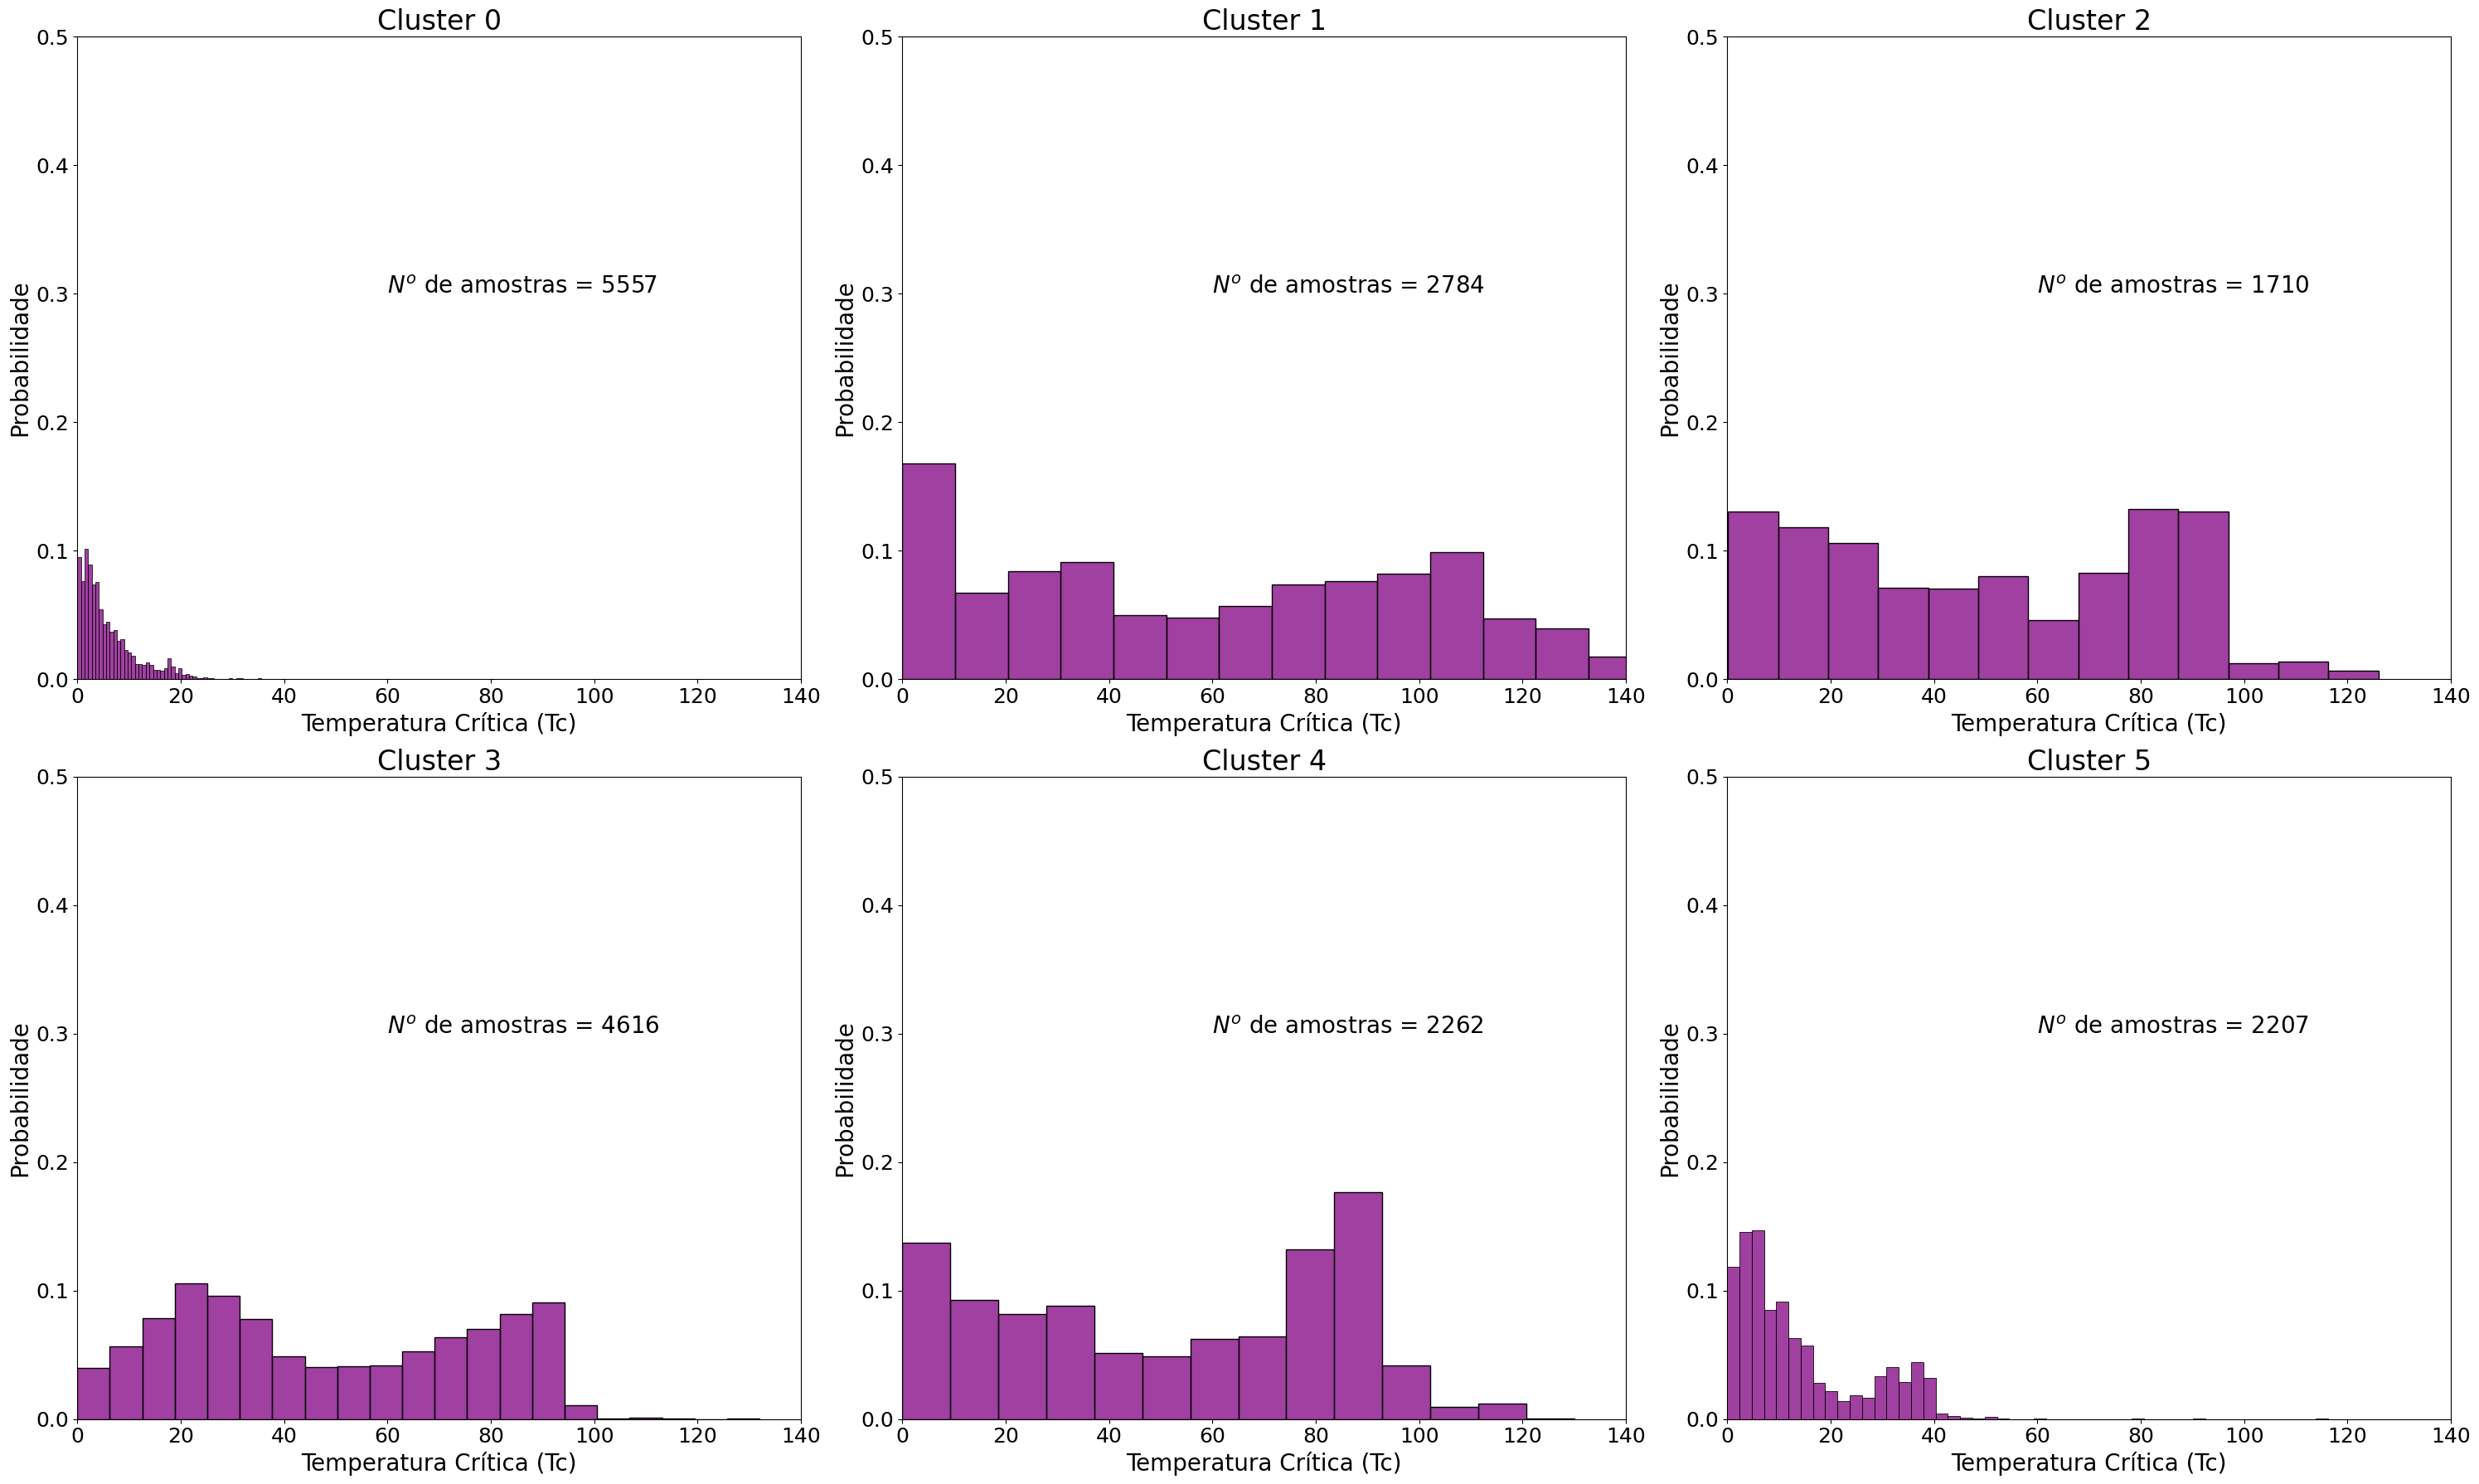

In [10]:
fig, axs = plt.subplots(2, 3, figsize=(30, 18))
axs = axs.flatten()


count = 0
for cluster in valid_clusters: 
    idx = np.where(cluster_labels == cluster)[0]

    axs[count].set_xlabel("Temperatura Crítica (Tc)", fontsize=20)
    axs[count].set_ylabel("Probabilidade", fontsize=20)

    X_cluster = X_train.iloc[idx]
    y_cluster = y_train.iloc[idx]

    sns.histplot(y_cluster, ax=axs[count], kde=False, stat="probability", color="purple") 
    coord_x = max(y_cluster)/2 
    axs[count].annotate(fr"$N^o$ de amostras = {len(y_cluster)}", xy=(60, 0.3), fontsize=20)
    axs[count].set_title(f"Cluster {cluster}", fontsize=24)
    axs[count].set_xlim(0, 140)
    axs[count].set_ylim(0, 0.5)
    axs[count].tick_params(axis='both', labelsize=18) 


    count += 1
    if count >= len(X_train.columns): 
        break

plt.tight_layout()
plt.show()

Now, it is possible to explore dependence plot of each cluster. Considering that our main objective is to understand more about superconductors with high critical temperature, cluster 1 will be choose for passing our analysis, because this clusters has more instances with temperature higher than 77K.

In [11]:
import sys
sys.path.append("../Main_Scripts")

from script_gam_interpretability import Clustering_GAM, cross_validation

clustering_gam = Clustering_GAM(bkmeans_gam, "normal", "identity", 25, 1.402388644873421)
cv_gam_results = cross_validation(X_train, y_train, X_test, bkmeans_gam, "normal", "identity", 1.402388644873421, 25, n_splits=10)
cv_gam_results

c:\Users\julia24002\.conda\envs\glm_gam\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but BisectingKMeans was fitted with feature names
  warnings.warn(
c:\Users\julia24002\.conda\envs\glm_gam\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but BisectingKMeans was fitted with feature names
  warnings.warn(
c:\Users\julia24002\.conda\envs\glm_gam\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but BisectingKMeans was fitted with feature names
  warnings.warn(
c:\Users\julia24002\.conda\envs\glm_gam\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but BisectingKMeans was fitted with feature names
  warnings.warn(
c:\Users\julia24002\.conda\envs\glm_gam\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but BisectingKMeans wa

{0: 10.953184859407964,
 1: 13.756213430329161,
 2: 11.703327389718385,
 3: 11.73171497661353,
 4: 13.097489817395259,
 5: 11.889409572478442,
 6: 11.329255913971496,
 7: 11.93363971023618,
 8: 11.561745341720526,
 9: 12.349486633433594,
 'Mean': 12.030546764530454,
 'Median': 11.810562274545987}

In [12]:
clustering_gam.fit(X_train, y_train, X_test)

,clusterer,BisectingKMea...om_state=1203)
,distribution,'normal'
,link,'identity'
,n_splines,25
,lam,1.402388644873421
,n_clusters,6
,init,'random'
,n_init,1
,random_state,1203
,max_iter,300
,verbose,0


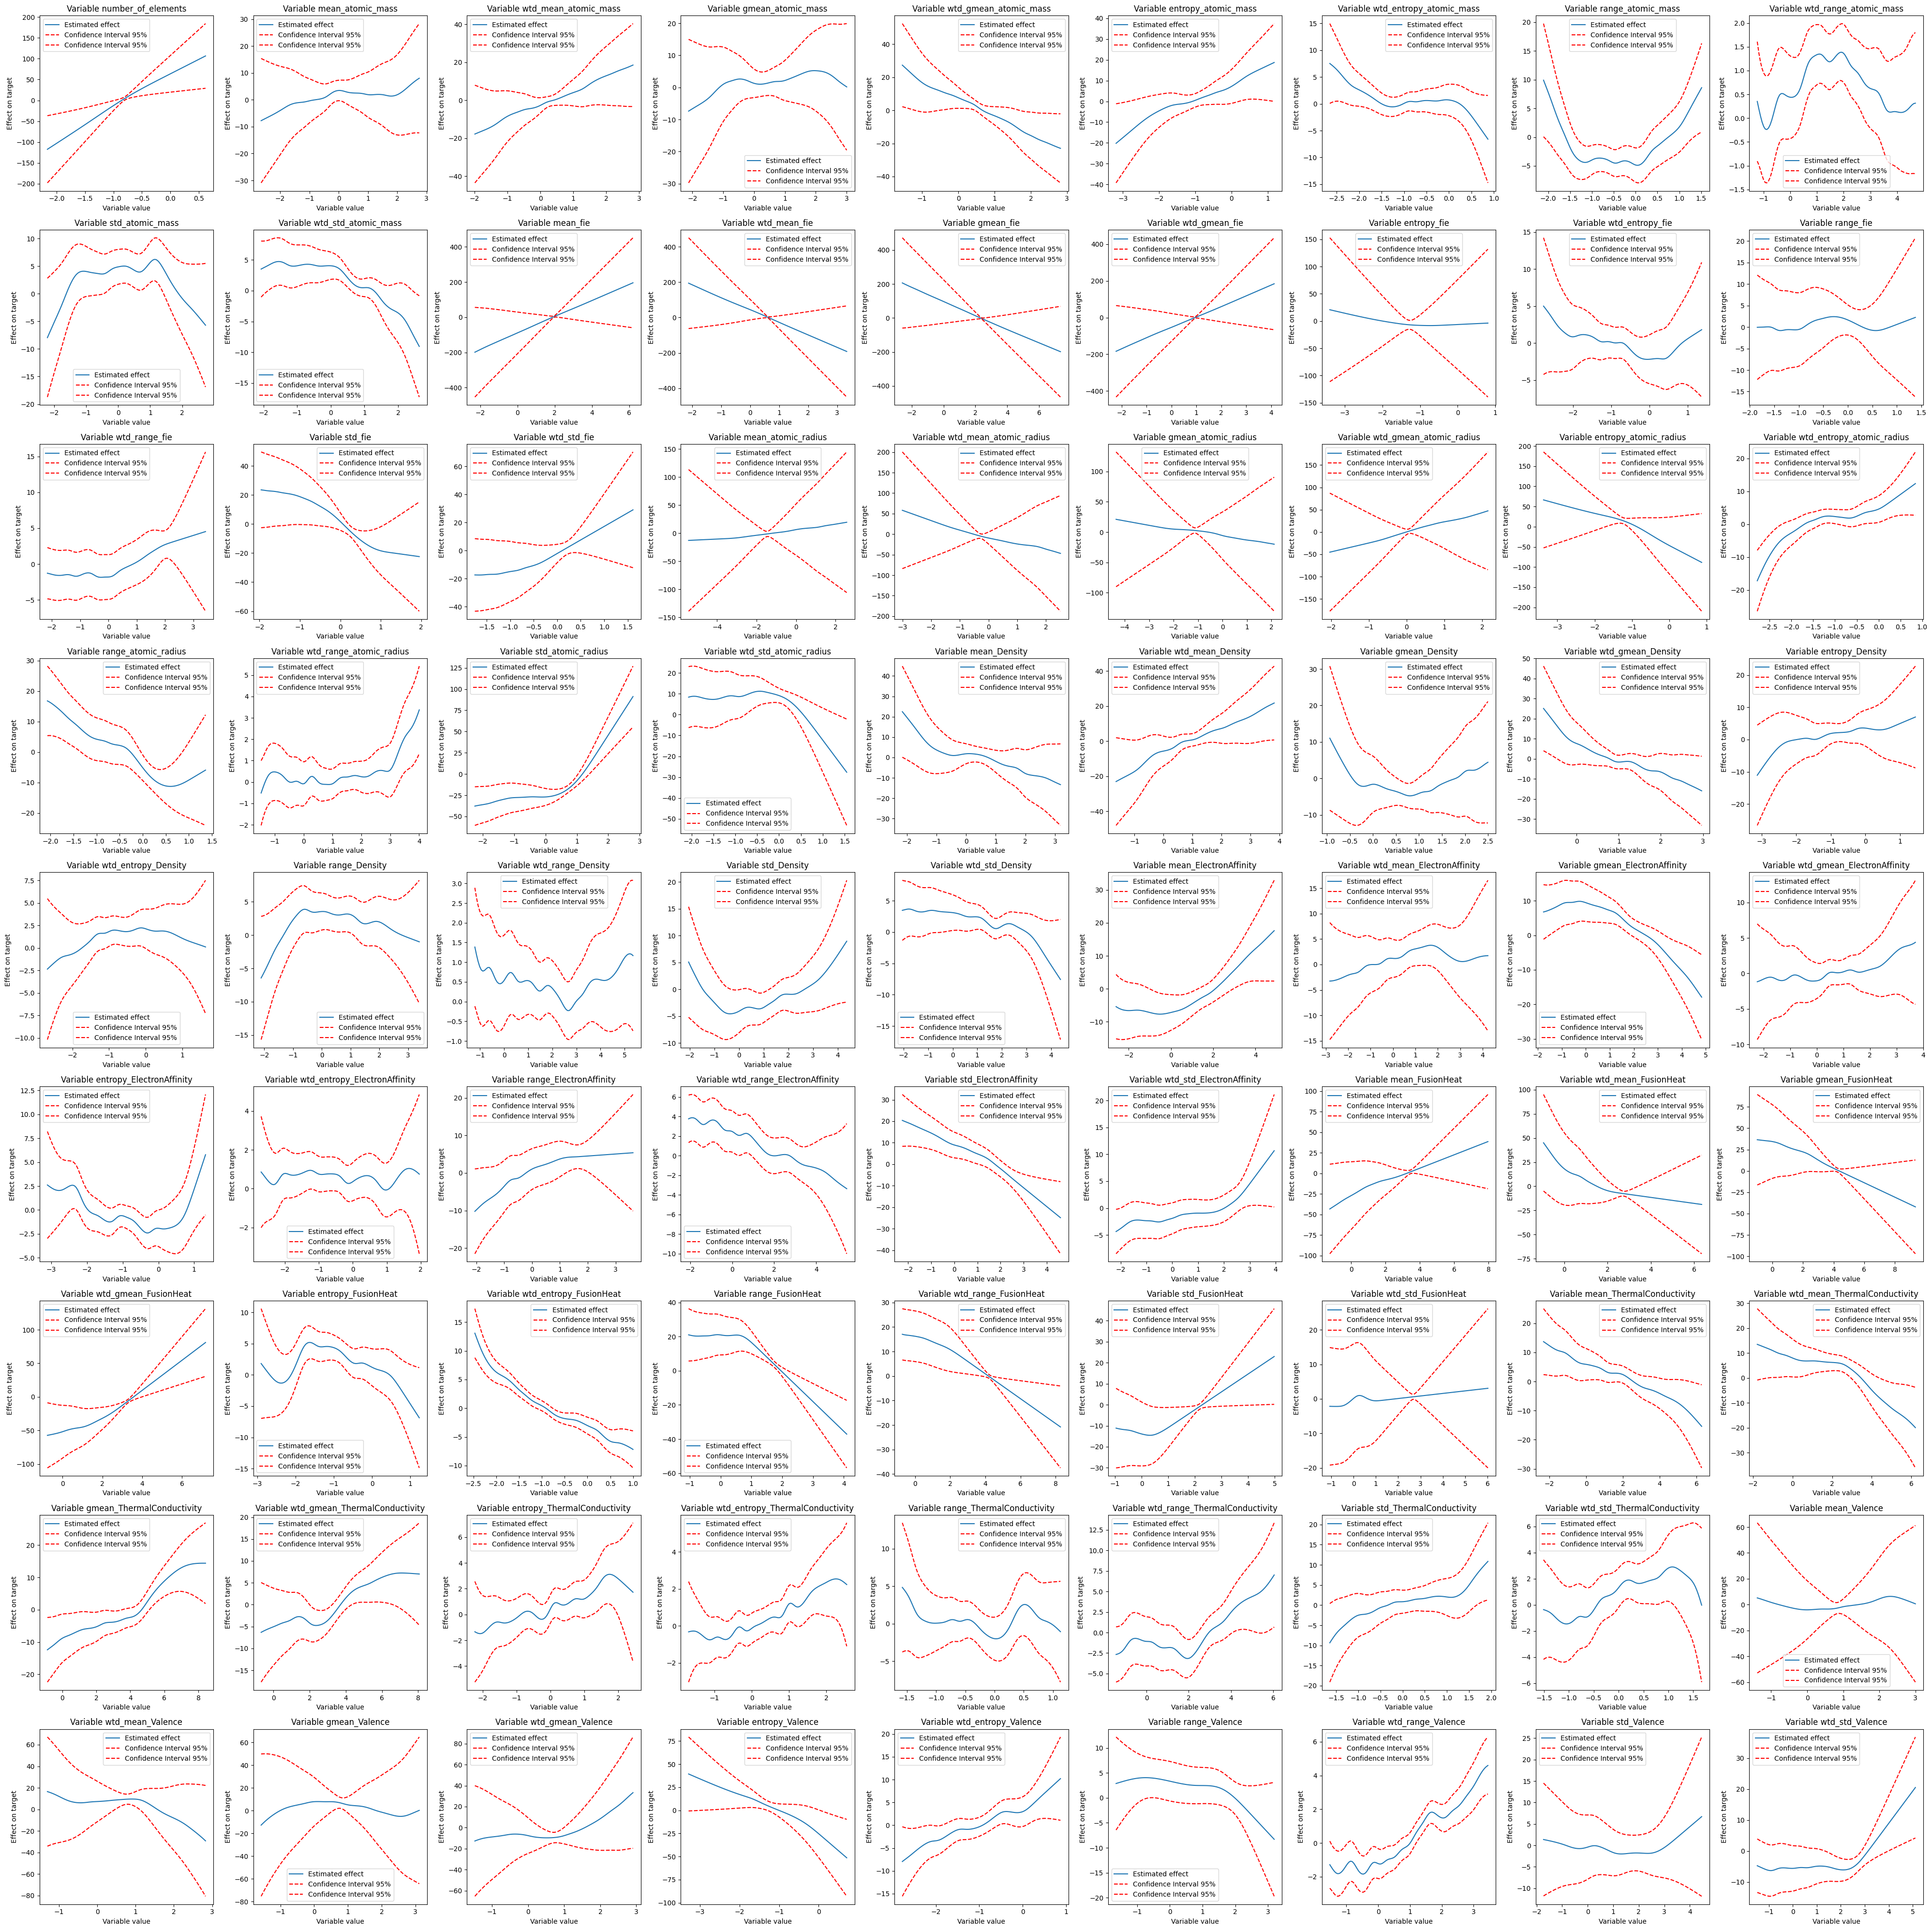

In [13]:
clustering_gam.partial_dependence_plot(cluster=1)

Now, we can visualize the main features by using shap for this cluster.

In [14]:
cluster_1_sv = clustering_gam.shap(cluster=1)

PermutationExplainer explainer:  31%|███▏      | 1194/3809 [5:47:49<17:48:02, 24.51s/it]